# Online Retail Business EDA
## 온라인 리테일 비즈니스 EDA

---

### Project Goal

**English**

This exploratory analysis aims to identify business growth opportunities for an online retail company.
The notebook is designed to answer several business questions **before** implementing the production pipeline.

**한국어**

이 노트북은 온라인 리테일 기업의 성장 기회를 찾기 위한 탐색적 데이터 분석(EDA)입니다.
실제 Pipeline을 구현하기 전에 데이터를 이해하고, 필요한 전처리를 결정하기 위한 목적입니다.

> **Note:** This notebook is NOT the final implementation.
> All validated logic will be moved into the `pipeline/` package later.
> 이 노트북은 최종 구현이 아닙니다. 검증된 로직은 나중에 `pipeline/` 패키지로 이동됩니다.

---
## Workflow
## 분석 흐름

**English**

Each business question follows the same structured workflow to ensure consistent and well-documented analysis.

**한국어**

각 비즈니스 질문은 일관성 있고 체계적인 분석을 위해 동일한 흐름을 따릅니다.

```
Business Question       비즈니스 질문 정의
        ↓
Relevant Columns        관련 컬럼 파악
        ↓
EDA                     탐색적 데이터 분석
        ↓
Observations            관찰 결과 기록
        ↓
Cleaning Decisions      전처리 결정
        ↓
Implement in Pipeline   Pipeline에 구현
```

---
## 1. Import Libraries
## 라이브러리 불러오기

**English**

Import the core libraries used throughout this notebook.

**한국어**

이 노트북 전반에서 사용하는 핵심 라이브러리를 불러옵니다.

| Library | Purpose | 용도 |
|---------|---------|------|
| `pandas` | Data manipulation and analysis | 데이터 조작 및 분석 |
| `numpy` | Numerical operations | 수치 연산 |
| `matplotlib.pyplot` | Static charts and plots | 정적 차트 |
| `seaborn` | Statistical visualisation | 통계 시각화 |
| `plotly.express` | Interactive charts | 인터랙티브 차트 |

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings (출력 설정)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 2. Load Dataset
## 데이터 불러오기

**English**

Load the Online Retail dataset from the `data/` folder.

**한국어**

`data/` 폴더에서 Online Retail 데이터셋을 불러옵니다.

In [120]:
df_raw = pd.read_excel("../data/online_retail.xlsx")
print(f"Dataset loaded: {len(df_raw):,} rows, {df_raw.shape[1]} columns")

Dataset loaded: 541,909 rows, 8 columns


### 2-1. First Rows — `head()`
**English** Check that the data loaded correctly and that column names make sense.  
**한국어** 데이터가 정상적으로 로드됐는지, 컬럼명이 올바른지 확인한다.

In [121]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


### 2-2. Shape — `shape`
**English** Get the total number of rows and columns.  
**한국어** 전체 행과 컬럼 수를 확인한다.

In [122]:
print(f"Rows   (행): {df_raw.shape[0]:,}")
print(f"Columns (열): {df_raw.shape[1]}")

Rows   (행): 541,909
Columns (열): 8


### 2-3. Data Types — `info()`
**English** Check whether data types are appropriate (e.g. dates should be datetime, not object).  
**한국어** 데이터 타입이 올바른지 확인한다. (날짜는 datetime이어야 함)

In [123]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


### 2-4. Descriptive Statistics — `describe()`
**English** Check the distribution of numeric columns — look for unexpected min/max values.  
**한국어** 수치 컬럼의 분포를 확인한다. 예상치 못한 min/max 값이 있는지 본다.

In [124]:
df_raw.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,"541,909.00",541909,540455,"541,909.00",541909,"541,909.00","406,829.00",541909
unique,"25,900.00",4070,4223,NaN,NaN,NaN,NaN,38
top,"573,585.00",85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,"1,114.00",2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.55,2011-07-04 13:34:57.156386,4.61,"15,287.69",NaN
min,NaN,NaN,NaN,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00",NaN
25%,NaN,NaN,NaN,1.00,2011-03-28 11:34:00,1.25,"13,953.00",NaN
50%,NaN,NaN,NaN,3.00,2011-07-19 17:17:00,2.08,"15,152.00",NaN
75%,NaN,NaN,NaN,10.00,2011-10-19 11:27:00,4.13,"16,791.00",NaN
max,NaN,NaN,NaN,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00",NaN


### 2-5. Missing Values
**English** Identify which columns have missing values and how many.  
**한국어** 어떤 컬럼에 결측값이 있고 얼마나 많은지 확인한다.

In [125]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"Missing Count (결측 수)": missing, "Missing % (결측 비율)": missing_pct})

,Missing Count (결측 수),Missing % (결측 비율)
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


---
## 3. Quick Dataset Overview
## 전체 데이터 빠르게 살펴보기

**English**

A lightweight pass over the full dataset to spot obvious issues.
This is NOT deep cleaning — just orientation.

**한국어**

전체 데이터를 가볍게 훑어보며 명확한 문제를 파악한다.
깊은 전처리가 아닌, 방향을 잡기 위한 단계다.

#### Duplicate Rows (중복 행)

In [126]:
duplicates = df_raw.duplicated().sum()
print(f"Duplicate rows (중복 행): {duplicates:,}")

Duplicate rows (중복 행): 5,268


#### Numeric Columns (수치 컬럼)

In [127]:
df_raw.select_dtypes(include='number').columns.tolist()

['Quantity', 'UnitPrice', 'CustomerID']

#### Categorical Columns (범주형 컬럼)

In [128]:
df_raw.select_dtypes(include='object').columns.tolist()

/var/folders/9d/hwl9yp1n3rv1y9j90spl8rmh0000gn/T/ipykernel_36610/1765358109.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.select_dtypes(include='object').columns.tolist()


['InvoiceNo', 'StockCode', 'Description', 'Country']

#### Date Range (데이터 기간)

In [129]:
print(f"Start (시작): {df_raw['InvoiceDate'].min()}")
print(f"End   (종료): {df_raw['InvoiceDate'].max()}")

Start (시작): 2010-12-01 08:26:00
End   (종료): 2011-12-09 12:50:00


---
## 4. Business Question 1 — Market Analysis
## 시장 분석

### Business Question
**English:** Which countries generate the most revenue, and what does the market look like excluding the UK?  
**한국어:** 어떤 국가가 가장 많은 매출을 발생시키며, 영국을 제외하면 어떤 시장이 성장 가능성이 있는가?

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `Country` | Segment revenue by market | 시장별 매출 분류 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |

### EDA

#### 4-1. Country — unique values and distribution
**한국어** 국가 unique 값 및 분포 확인

In [130]:
# ==========================================================
# Country — Unique Values and Distribution
# 국가 unique 값 및 분포 확인
# ==========================================================

# 1. Basic Statistics
# 기본 통계
country_count = df_raw["Country"].value_counts()
country_count_pct = (country_count / len(df_raw) * 100).round(2)

print(f"Unique countries (고유 국가): {df_raw['Country'].nunique()}")
display(pd.DataFrame({
    "Count (빈도)": country_count,
    "Count % (빈도 비율)": country_count_pct,
}))

# Note: United Kingdom accounts for ~91.43% of transactions
# 참고: United Kingdom이 전체 거래의 약 91.43%를 차지함


Unique countries (고유 국가): 38


,Count (빈도),Count % (빈도 비율)
Country,,
United Kingdom,495478,91.43
Germany,9495,1.75
France,8557,1.58
EIRE,8196,1.51
Spain,2533,0.47
Netherlands,2371,0.44
Belgium,2069,0.38
Switzerland,2002,0.37
Portugal,1519,0.28


In [131]:
# ==========================================================
# Rename Country Labels
# 국가명 변경
# ==========================================================

# EIRE → Ireland, RSA → Republic of South Africa
rename_countries = {
    "EIRE": "Ireland",
    "RSA": "Republic of South Africa",
}

df_raw["Country"] = df_raw["Country"].replace(rename_countries)


In [132]:
# ==========================================================
# Exclude Ambiguous Countries
# 애매한 국가 제외
# ==========================================================

# Remove Unspecified, European Community
exclude_countries = ["Unspecified", "European Community"]
df_raw = df_raw[~df_raw["Country"].isin(exclude_countries)]

print(f"Excluded countries (제외된 국가): {exclude_countries}")
print(f"Remaining rows (남은 행): {len(df_raw):,}")


Excluded countries (제외된 국가): ['Unspecified', 'European Community']
Remaining rows (남은 행): 541,402


In [133]:
# ==========================================================
# Country Distribution Excluding UK
# UK 제외 국가 분포
# ==========================================================

country_count_without_uk = (
    df_raw[df_raw["Country"] != "United Kingdom"]["Country"]
    .value_counts()
)
country_count_without_uk_pct = (
    country_count_without_uk
    / len(df_raw[df_raw["Country"] != "United Kingdom"])
    * 100
).round(2)

print("Sales frequency by country — excluding UK (UK 제외 국가별 판매 빈도)")
display(pd.DataFrame({
    "Count (빈도)": country_count_without_uk,
    "Count % (빈도 비율)": country_count_without_uk_pct,
}))


Sales frequency by country — excluding UK (UK 제외 국가별 판매 빈도)


,Count (빈도),Count % (빈도 비율)
Country,,
Germany,9495,20.68
France,8557,18.63
Ireland,8196,17.85
Spain,2533,5.52
Netherlands,2371,5.16
Belgium,2069,4.51
Switzerland,2002,4.36
Portugal,1519,3.31
Australia,1259,2.74


#### 4-2. Negative or zero Quantity
**한국어** Quantity 음수/0 여부 확인

In [134]:
# ==========================================================
# Negative Quantity Investigation
# Quantity 음수 데이터 조사
# ==========================================================

# 1. Basic Statistics
# 기본 통계
negative_quantity = df_raw[df_raw["Quantity"] <= 0]

negative_count = len(negative_quantity)
negative_pct = negative_count / len(df_raw) * 100

print(f"Negative Quantity Rows : {negative_count:,} ({negative_pct:.2f}%)")

display(negative_quantity.head())

Negative Quantity Rows : 10,623 (1.96%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,"14,527.00",United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom


In [135]:
# ==========================================================
# Compare Negative Quantity vs Cancelled Invoice
# 음수 Quantity와 취소 주문 비교
# ==========================================================

is_negative = df_raw["Quantity"] <= 0
is_cancelled = df_raw["InvoiceNo"].astype(str).str.startswith("C")

print(f"Negative Quantity         : {is_negative.sum():,}")
print(f"Cancelled Invoice (C)     : {is_cancelled.sum():,}")
print(f"Overlap                   : {(is_negative & is_cancelled).sum():,}")
print(f"Negative Only             : {(is_negative & ~is_cancelled).sum():,}")
print(f"Cancelled Only            : {(~is_negative & is_cancelled).sum():,}")

Negative Quantity         : 10,623
Cancelled Invoice (C)     : 9,287
Overlap                   : 9,287
Negative Only             : 1,336
Cancelled Only            : 0


In [136]:
# ==========================================================
# Investigate Negative Quantity without Cancelled Invoice
# C Invoice가 아닌 음수 Quantity 조사
# ==========================================================

negative_only = df_raw[is_negative & ~is_cancelled]

display(
    negative_only[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "CustomerID",
        ]
    ]
)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
2406,536589,21777,NaN,-10,0.00,NaN
4347,536764,84952C,NaN,-38,0.00,NaN
7188,536996,22712,NaN,-20,0.00,NaN
7189,536997,22028,NaN,-20,0.00,NaN
7190,536998,85067,NaN,-6,0.00,NaN
...,...,...,...,...,...,...
535333,581210,23395,check,-26,0.00,NaN
535335,581212,22578,lost,-1050,0.00,NaN
535336,581213,22576,check,-30,0.00,NaN
536908,581226,23090,missing,-338,0.00,NaN


In [137]:
# ==========================================================
# Check UnitPrice & Description
# UnitPrice와 Description 확인
# ==========================================================

print(f"Total Rows           : {len(negative_only):,}")
print(f"UnitPrice == 0       : {(negative_only['UnitPrice'] == 0).sum():,}")
print(f"UnitPrice != 0       : {(negative_only['UnitPrice'] != 0).sum():,}")
print(f"All UnitPrice == 0 ? : {(negative_only['UnitPrice'] == 0).all()}")

print("\nUnique Descriptions")
display(
    sorted(
        negative_only["Description"]
        .dropna()
        .astype(str)
        .unique()
    )
)

Total Rows           : 1,336
UnitPrice == 0       : 1,336
UnitPrice != 0       : 0
All UnitPrice == 0 ? : True

Unique Descriptions


['20713',
 '20713 wrongly marked',
 '?',
 '? sold as sets?',
 '??',
 '?? missing',
 '???',
 '????damages????',
 '????missing',
 '???lost',
 '???missing',
 '?display?',
 '?lost',
 '?missing',
 '?sold as sets?',
 'Amazon sold sets',
 'Breakages',
 'CHECK',
 'Crushed',
 'DAMAGED',
 'Dagamed',
 'Damaged',
 'Damages',
 'Damages/samples',
 'Display',
 'Dotcom',
 'Dotcom sales',
 'Dotcom set',
 "Dotcom sold in 6's",
 'Given away',
 'Incorrect stock entry.',
 'MERCHANT CHANDLER CREDIT ERROR, STO',
 'MIA',
 'Missing',
 'Not rcvd in 10/11/2010 delivery',
 'OOPS ! adjustment',
 'POSSIBLE DAMAGES OR LOST?',
 'Printing smudges/thrown away',
 'Show Samples',
 'Sold as 1 on dotcom',
 'Thrown away-rusty',
 'Thrown away.',
 'Unsaleable, destroyed.',
 'WET/MOULDY',
 'Water damaged',
 'Wet pallet-thrown away',
 'Wrongly mrked had 85123a in box',
 'adjust',
 'adjustment',
 'barcode problem',
 'broken',
 "can't find",
 'check',
 'code mix up? 84930',
 'counted',
 'cracked',
 'crushed',
 'crushed boxes',
 '

#### 4-3. Negative or zero UnitPrice
**한국어** UnitPrice 음수/0 여부 확인

In [138]:
# ==========================================================
# Negative or Zero UnitPrice Investigation
# UnitPrice 음수/0 데이터 조사
# ==========================================================

# 1. Basic Statistics
# 기본 통계
negative_unitprice = df_raw[df_raw["UnitPrice"] <= 0]
negative_unitprice_count = len(negative_unitprice)
negative_unitprice_pct = round(negative_unitprice_count / len(df_raw) * 100, 2)

print(f"UnitPrice <= 0 rows : {negative_unitprice_count:,} ({negative_unitprice_pct}%)")
display(negative_unitprice.head())
display(df_raw[df_raw["UnitPrice"] < 0].head())


UnitPrice <= 0 rows : 2,517 (0.46%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",NaN,United Kingdom


In [139]:
# ==========================================================
# UnitPrice = 0 with Positive Quantity
# UnitPrice = 0 이지만 Quantity > 0 인 행
# ==========================================================

free_items = df_raw[
    (df_raw["Quantity"] > 0) &
    (df_raw["UnitPrice"] == 0)
]

print(f"UnitPrice = 0 & Quantity > 0 : {len(free_items):,}")
display(free_items.head(20))


UnitPrice = 0 & Quantity > 0 : 1,179


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.00,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.00,NaN,United Kingdom
4348,536765,84952C,NaN,19,2010-12-02 14:43:00,0.00,NaN,United Kingdom


In [140]:
# ==========================================================
# Check Description Patterns
# Description 패턴 확인
# ==========================================================

print(f"Description NaN : {free_items['Description'].isna().mean() * 100:.2f}%")
display(free_items["Description"].value_counts(dropna=False))


Description NaN : 50.21%


Description
NaN                                    592
check                                   39
found                                   25
adjustment                              14
FRENCH BLUE METAL DOOR SIGN 1            9
                                      ... 
dotcom adjust                            1
check?                                   1
ASSTD DESIGN 3D PAPER STICKERS           1
FRIDGE MAGNETS LES ENFANTS ASSORTED      1
CLASSIC GLASS COOKIE JAR                 1
Name: count, Length: 247, dtype: int64

In [141]:
# ==========================================================
# Check CustomerID Patterns
# CustomerID 패턴 확인
# ==========================================================

print(f"CustomerID NaN : {free_items['CustomerID'].isna().mean() * 100:.2f}%")
display(free_items["CustomerID"].value_counts(dropna=False))


CustomerID NaN : 96.61%


CustomerID
NaN          1139
13,081.00       4
14,646.00       4
14,911.00       2
12,415.00       2
13,985.00       2
12,647.00       1
16,560.00       1
15,107.00       1
17,560.00       1
13,239.00       1
13,113.00       1
14,410.00       1
12,457.00       1
17,667.00       1
16,818.00       1
12,507.00       1
15,581.00       1
16,133.00       1
12,748.00       1
15,804.00       1
12,446.00       1
18,059.00       1
14,110.00       1
12,437.00       1
12,431.00       1
13,014.00       1
15,602.00       1
12,603.00       1
12,444.00       1
16,406.00       1
13,256.00       1
Name: count, dtype: int64

#### 4-4. Visualisation placeholder
**한국어** 시각화 자리

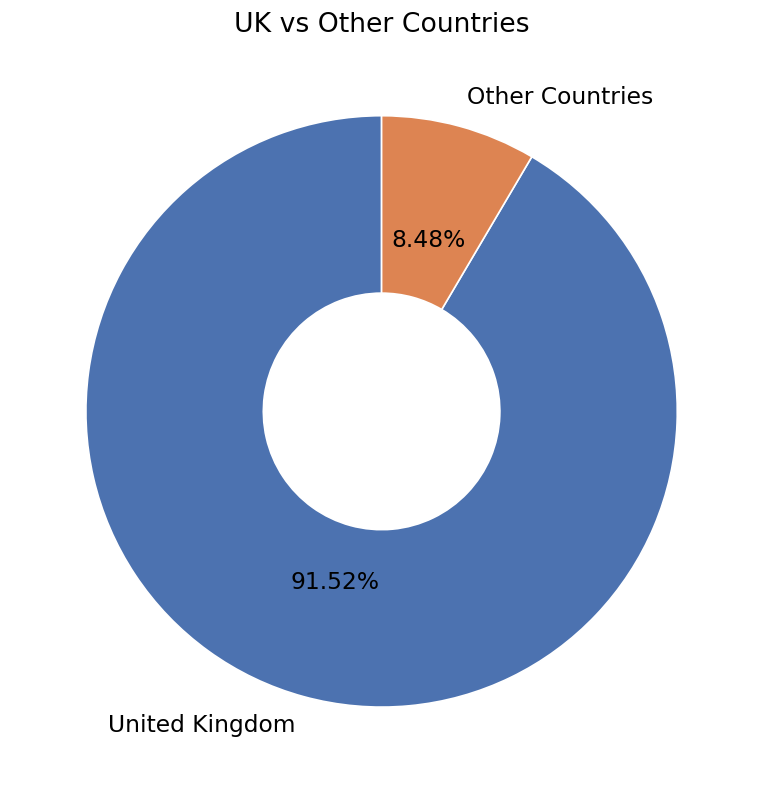

In [142]:
# ==========================================================
# Visualisation — UK vs Other Countries (Donut Chart)
# 시각화 — UK vs 기타 국가 (도넛 차트)
# ==========================================================

uk_count = country_count["United Kingdom"]
others_count = len(df_raw) - uk_count

labels = ["United Kingdom", "Other Countries"]
sizes = [uk_count, others_count]
colors = ["#4C72B0", "#DD8452"]

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.2f%%",
    startangle=90,
    textprops={"fontsize": 14},
    wedgeprops={"edgecolor": "white", "width": 0.6},
)
plt.title("UK vs Other Countries", fontsize=16)
plt.show()


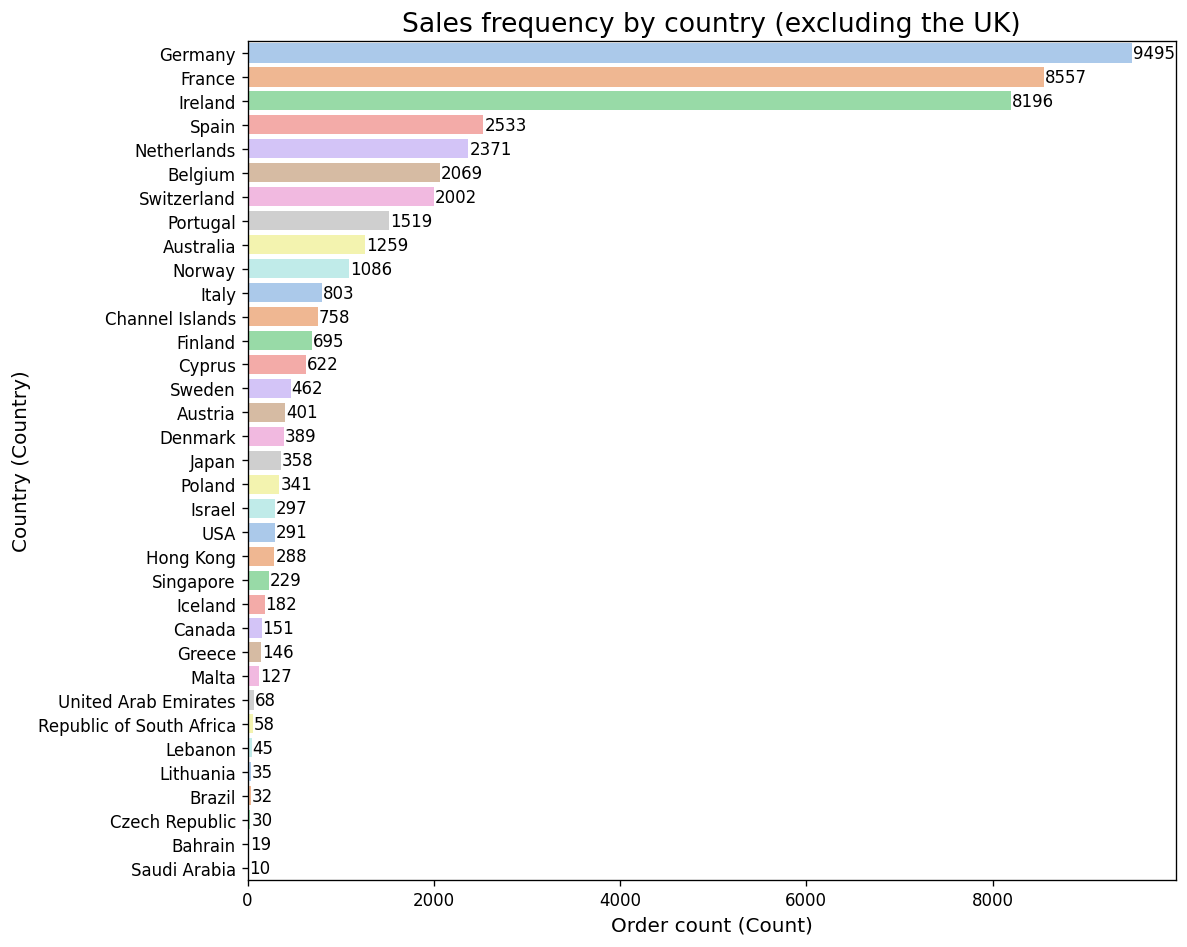

In [143]:
# ==========================================================
# Visualisation — Sales Frequency by Country (Excluding UK)
# 시각화 — UK 제외 국가별 판매 빈도 (막대 차트)
# ==========================================================

plt.figure(figsize=(10, 8))

sns.barplot(
    x=country_count_without_uk.values,
    y=country_count_without_uk.index,
    hue=country_count_without_uk.index,
    palette="pastel",
    legend=False,
)

plt.title("Sales frequency by country (excluding the UK)", fontsize=16)
plt.xlabel("Order count (Count)", fontsize=12)
plt.ylabel("Country (Country)", fontsize=12)

for i, v in enumerate(country_count_without_uk.values):
    plt.text(v + 10, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()


### Observations
### 관찰 결과

> **English** — What did you notice? Is there any data quality issue? Does anything require cleaning?  
> **한국어** — 어떤 점을 발견했는가? 데이터 품질 문제가 있는가? 전처리가 필요한 부분이 있는가?

**Country (국가)**
- United Kingdom accounts for ~91% of transactions, dominating the dataset. Other countries are barely visible in a single chart.  
  UK가 전체 거래의 약 91%를 차지해, 한 차트로는 다른 국가가 거의 보이지 않는다.
- Ambiguous country labels exist: `Unspecified`, `European Community`.  
  `Unspecified`, `European Community`처럼 애매한 국가명이 있다.
- `EIRE` and `RSA` should be renamed to `Ireland` and `Republic of South Africa` for clarity.  
  `EIRE`, `RSA`는 `Ireland`, `Republic of South Africa`로 이름을 정리하는 것이 좋다.

**Quantity (수량)**
- 10,624 rows have `Quantity < 0`; 9,288 rows have `InvoiceNo` starting with `C`. The counts are **not identical**.  
  `Quantity < 0`은 10,624건, `C` 인보이스는 9,288건으로 **개수가 같지 않다**.
- All `C` invoices have negative Quantity; no `C` invoice has positive Quantity.  
  `C` 인보이스는 전부 Quantity가 음수이고, 양수인 `C` 인보이스는 없다.
- 1,336 rows have negative Quantity but **no** `C` prefix — all have `UnitPrice = 0`.  
  Quantity 음수인데 `C`가 아닌 행 1,336건은 **전부 UnitPrice = 0**이다.
- Descriptions in those 1,336 rows include `check`, `damaged`, `damages`, `adjustment`, `amazon`, etc. — internal records, not sales.  
  Description에 `check`, `damaged`, `amazon` 등이 들어 있어 실제 판매가 아니라 내부 기록으로 보인다.

**UnitPrice (단가)**
- 2,515 rows have `UnitPrice = 0`; 2 rows have `UnitPrice < 0` (`Adjust bad debt`, -£11,062.06).  
  `UnitPrice = 0`은 2,515건, `UnitPrice < 0`은 2건(부실채권 조정)이다.
- Among `UnitPrice <= 0` rows: ~50% have `Description` NaN; ~96.6% have `CustomerID` NaN.  
  `UnitPrice <= 0` 행 중 Description NaN 약 50%, CustomerID NaN 약 96.6%다.
- Some `UnitPrice = 0` rows have a Description (`amazon`, `check`, `damaged`) and even a CustomerID (40 rows) — still **£0 revenue**.  
  Description이나 CustomerID가 있어도 UnitPrice=0이면 **매출 £0**이다.
- Filtering `UnitPrice > 0` removes 40 customer-linked rows, but they contribute no revenue (0.007% of total rows).  
  `UnitPrice > 0` 필터 시 CustomerID 있는 40건도 빠지지만, 매출 기여는 0이고 전체의 0.007%에 불과하다.

---

### Cleaning Decisions
### 전처리 결정

- [x] Remove rows where `Quantity <= 0` (cancellations + inventory adjustments, not sales)  
  `Quantity <= 0` 제거 — 취소·재고 조정이며 실제 판매 아님
- [x] Remove rows where `UnitPrice <= 0` (zero-revenue and accounting adjustment records)  
  `UnitPrice <= 0` 제거 — 매출 0 또는 회계 조정 기록
- [x] Create `Revenue = Quantity × UnitPrice` column  
  `Revenue = Quantity × UnitPrice` 컬럼 생성
- [x] Rename countries: `EIRE` → `Ireland`, `RSA` → `Republic of South Africa`  
  국가명 정리: `EIRE` → `Ireland`, `RSA` → `Republic of South Africa`
- [x] Exclude ambiguous countries: `Unspecified`, `European Community`  
  `Unspecified`, `European Community` 제외
- [x] Do **not** remove UK — run Q1 analysis both with and without UK  
  UK는 제거하지 않고, UK 포함/제외 두 버전으로 Q1 분석
- [] Do **not** remove UK — run Q1 analysis both with and without UK  
  제거할 값들의 Country 도 파악하기

---
## 5. Business Question 2 — Sales Trend Analysis
## 매출 추이 분석

### Business Question
**English:** How has monthly revenue trended over time, and what seasonality exists?  
**한국어:** 월별 매출 추이가 어떻게 변해왔으며, 어떤 계절성이 있는가?

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `InvoiceDate` | Extract year/month for grouping | 연/월 추출 후 그룹화 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |

### EDA

#### 5-1. Date range and dtype check
**한국어** 날짜 범위 및 dtype 확인

In [144]:
# Date range
# 날짜 범위
print(f"Start (시작): {df_raw['InvoiceDate'].min()}")
print(f"End   (종료): {df_raw['InvoiceDate'].max()}")

Start (시작): 2010-12-01 08:26:00
End   (종료): 2011-12-09 12:50:00


#### 5-2. Monthly transaction count — any gaps?
**한국어** 월별 거래 건수 및 누락된 달 확인

In [145]:
# Monthly transaction count
# 월별 거래 건수

# '%Y-%m' 형식(예: 2011-12)으로 글자를 뽑아내서 'YearMonth'라는 새 컬럼에 저장
df_raw['YearMonth'] = df_raw['InvoiceDate'].dt.strftime('%Y-%m')
monthly_items = df_raw.groupby('YearMonth').size()

display(monthly_items)

YearMonth
2010-12    42481
2011-01    35147
2011-02    27707
2011-03    36748
2011-04    29889
2011-05    36972
2011-06    36844
2011-07    39268
2011-08    35261
2011-09    50160
2011-10    60742
2011-11    84658
2011-12    25525
dtype: int64

#### 5-3. Visualisation placeholder
**한국어** 시각화 자리

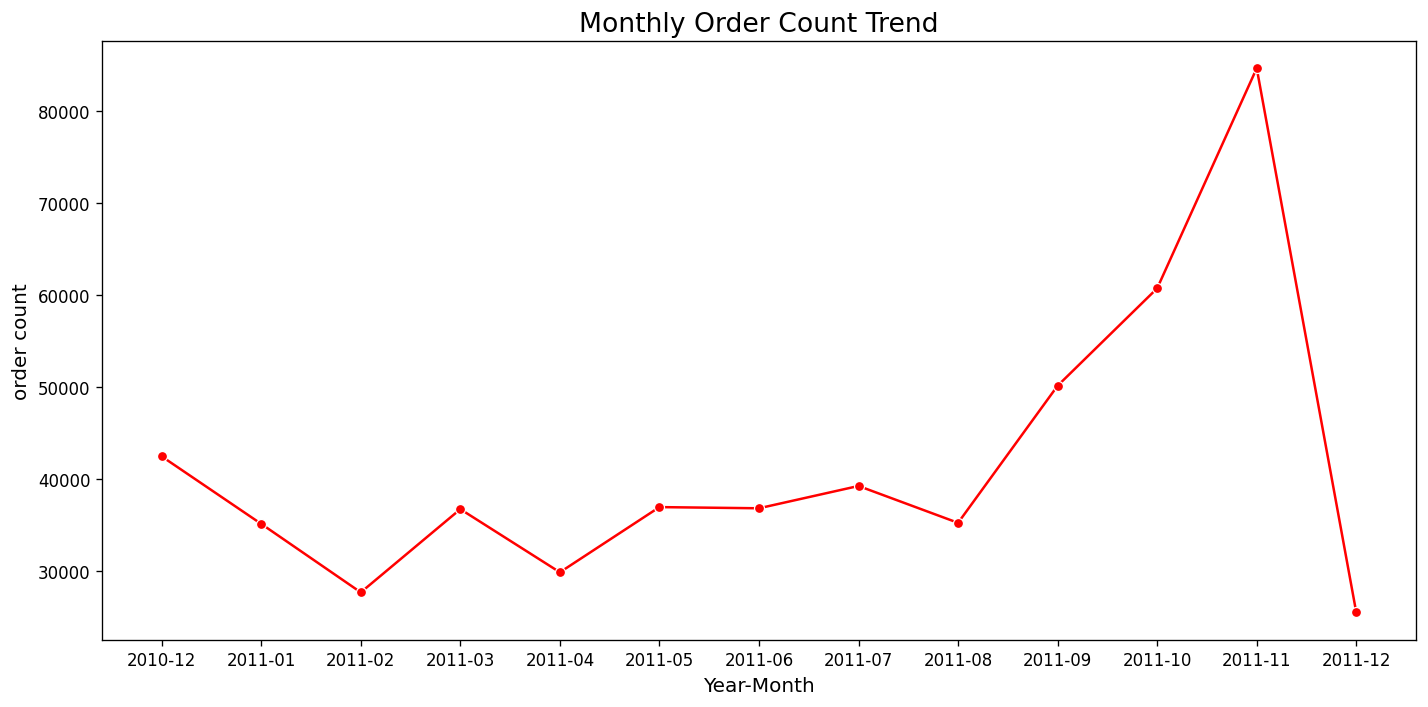

In [146]:
# Line chart — monthly order count trend
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_items.index,
    y=monthly_items.values,
    marker='o',
    color='red'
)

plt.title("Monthly Order Count Trend", fontsize=16)
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("order count", fontsize=12)

plt.tight_layout()
plt.show()

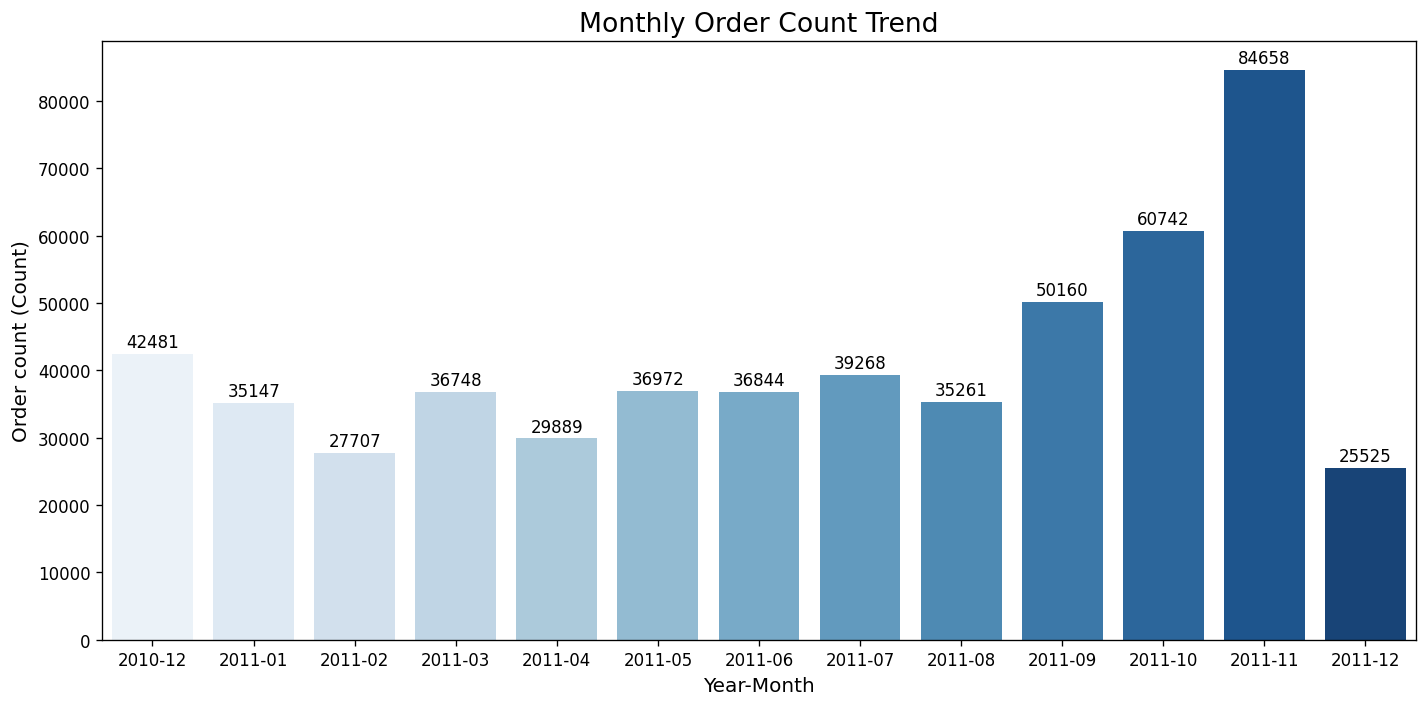

In [147]:
# ==========================================================
# Visualisation — Monthly Order Count Trend (Bar Chart)
# 시각화 — 월별 판매 건수 추이 (세로 막대 차트)
# ==========================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    x=monthly_items.index,
    y=monthly_items.values,
    hue=monthly_items.index,
    palette="Blues",
    legend=False,
)

plt.title("Monthly Order Count Trend", fontsize=16)
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Order count (Count)", fontsize=12)

for i, v in enumerate(monthly_items.values):
    plt.text(i, v + 1000, str(v), ha="center", fontsize=10) 

plt.tight_layout()
plt.show()

### Observations
### 관찰 결과

> **English** — What did you notice about the trend? Any gaps or anomalies?  
> **한국어** — 추이에서 어떤 점을 발견했는가? 공백이나 이상값이 있는가?

**Monthly Revenue Trend (월별 매출 추이)**
- November 2011 shows a sharp revenue spike — likely driven by Black Friday and the holiday shopping season.  
  2011년 11월 매출이 크게 급등했으며, Black Friday와 연말 쇼핑 시즌 영향으로 보인다.
- Revenue rises steadily from September through November, suggesting increased consumer spending in autumn.  
  9월부터 11월까지 매출이 점진적으로 증가해, 가을철 소비가 늘어나는 추세로 보인다.
- December 2011 data only covers up to the 9th, so transaction volume and revenue appear lower than other months — this is a data coverage issue, not a real sales drop.  
  2011년 12월 데이터는 9일까지만 있어 다른 달보다 거래량·매출이 적어 보인다 — 실제 매출 하락이 아니라 **데이터 기간 문제**다.

---

### Cleaning Decisions
### 전처리 결정

- [x] Extract `YearMonth` column for monthly aggregation  
  월별 집계를 위해 `YearMonth` 컬럼 생성
- [x] When comparing monthly revenue, note that December 2011 is a partial month (data ends 2011-12-09) — exclude or annotate in charts
  월별 매출 비교 시 2011년 12월은 부분 데이터(12/9까지)이므로 차트에서 **제외하거나 주석 표시**
- [ ] Apply shared cleaning from Q1: `Quantity > 0`, `UnitPrice > 0` before calculating monthly revenue  
  Q1 공통 전처리(`Quantity > 0`, `UnitPrice > 0`) 적용 후 월별 매출 계산

---
## 6. Business Question 3 — Product Performance
## 상품 성과 분석

### Business Question
**English:** Which products generate the most revenue, and do the top 20% of products account for 80% of revenue? (Pareto Principle)  
**한국어:** 어떤 상품이 매출을 가장 많이 만드는가? 상위 20% 상품이 전체 매출의 80%를 차지하는가? (파레토 원칙)

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `Description` | Identify products | 상품 식별 |
| `StockCode` | Identify special/non-product entries | 특수/비상품 항목 식별 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |

### EDA

#### 6-1. Missing Description
**한국어** Description 결측값 확인

In [148]:
# Missing Description count
# Description 결측값 수
description_nan = df_raw[df_raw["Description"].isna()]
display(description_nan)

description_customer_nan = df_raw[(df_raw["Description"].isna()) & (df_raw["CustomerID"].notna())]
print(len(description_customer_nan))
# description이 NaN이면 UnitPrice도 NaN

description_unitprice_nan = df_raw[(df_raw["Description"].isna()) & (df_raw["UnitPrice"] > 0)]
print(len(description_unitprice_nan))
# description이 NaN이면 UnitPrice가 0이라서 어차피 걸러질 것들

filtered_df = df_raw[df_raw["Description"].notna() & (df_raw["UnitPrice"] > 0) & (df_raw["Quantity"] > 0)]
display(filtered_df["Description"].value_counts())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,YearMonth
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,2010-12
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom,2010-12
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom,2010-12
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom,2010-12
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom,2010-12
...,...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.00,NaN,United Kingdom,2011-12
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.00,NaN,United Kingdom,2011-12
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.00,NaN,United Kingdom,2011-12
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.00,NaN,United Kingdom,2011-12


0
0


Description
WHITE HANGING HEART T-LIGHT HOLDER     2323
JUMBO BAG RED RETROSPOT                2112
REGENCY CAKESTAND 3 TIER               2015
PARTY BUNTING                          1706
LUNCH BAG RED RETROSPOT                1592
                                       ... 
LARGE HEART FLOWERS HOOK                  1
SET 10 CARDS SNOWY ROBIN 17099            1
SET 10 CARDS SWIRLY XMAS TREE 17104       1
LETTER "U" BLING KEY RING                 1
PAPER CRAFT , LITTLE BIRDIE               1
Name: count, Length: 4026, dtype: int64

#### 6-2. Non-product Description values
**한국어** 비상품 Description 값 확인 (check, damaged, NaN 등)

In [149]:
# ==========================================================
# Filter Valid Sales Rows
# 유효 판매 행만 필터링
# ==========================================================

# Description notna + UnitPrice > 0 + Quantity > 0
filtered_df = df_raw[
    df_raw["Description"].notna()
    & (df_raw["UnitPrice"] > 0)
    & (df_raw["Quantity"] > 0)
].copy()

filtered_df["Revenue"] = filtered_df["Quantity"] * filtered_df["UnitPrice"]

print(f"Filtered rows : {len(filtered_df):,}")
print(f"Unique Description : {filtered_df['Description'].nunique():,}")


Filtered rows : 529,598
Unique Description : 4,026


In [150]:
# ==========================================================
# Revenue by Description (Top 20%)
# Description별 매출 — 상위 20%
# ==========================================================

product_revenue = (
    filtered_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_20pct_n = int(len(product_revenue) * 0.2)
top_products = product_revenue.head(top_20pct_n)

print(f"Total products : {len(product_revenue):,}")
print(f"Top 20% count  : {top_20pct_n:,}")
display(top_products.head(20))


Total products : 4,026
Top 20% count  : 805


Description
DOTCOM POSTAGE                       206,248.77
REGENCY CAKESTAND 3 TIER             174,459.24
PAPER CRAFT , LITTLE BIRDIE          168,469.60
WHITE HANGING HEART T-LIGHT HOLDER   106,292.77
PARTY BUNTING                         99,504.33
JUMBO BAG RED RETROSPOT               94,340.05
MEDIUM CERAMIC TOP STORAGE JAR        81,700.92
Manual                                78,112.82
POSTAGE                               77,960.88
RABBIT NIGHT LIGHT                    66,937.95
PAPER CHAIN KIT 50'S CHRISTMAS        64,952.29
ASSORTED COLOUR BIRD ORNAMENT         59,057.75
CHILLI LIGHTS                         54,117.76
SPOTTY BUNTING                        42,548.13
JUMBO BAG PINK POLKADOT               42,436.24
BLACK RECORD COVER FRAME              40,652.13
PICNIC BASKET WICKER 60 PIECES        39,619.50
DOORMAT KEEP CALM AND COME IN         38,158.69
SET OF 3 CAKE TINS PANTRY DESIGN      38,128.69
JAM MAKING SET WITH JARS              37,032.88
Name: Revenue, dtype: float6

In [151]:
# ==========================================================
# Find Suspicious Descriptions in Top 20%
# 상위 20% 중 의심 Description 찾기
# ==========================================================

keywords = [
    "postage", "manual", "amazon", "fee", "discount",
    "sample", "bank", "voucher", "carriage", "adjust",
]
pattern = "|".join(keywords)

suspicious = top_products[
    top_products.index.str.contains(pattern, case=False, na=False)
]

print(f"Suspicious in top 20%: {len(suspicious)}")
display(suspicious)


Suspicious in top 20%: 18


Description
DOTCOM POSTAGE                        206,248.77
Manual                                 78,112.82
POSTAGE                                77,960.88
SET OF TEA COFFEE SUGAR TINS PANTRY    23,494.37
AMAZON FEE                             13,761.09
SET 3 RETROSPOT TEA,COFFEE,SUGAR       11,407.56
Adjust bad debt                        11,062.06
LONDON BUS COFFEE MUG                  10,224.75
PIGGY BANK RETROSPOT                    7,121.38
CARRIAGE                                7,051.00
COFFEE MUG APPLES DESIGN                6,353.55
QUEENS GUARD COFFEE MUG                 5,849.29
CERAMIC STRAWBERRY CAKE MONEY BANK      5,695.77
COFFEE MUG PEARS  DESIGN                5,136.84
COFFEE MUG CAT + BIRD DESIGN            5,031.83
CERAMIC HEART FAIRY CAKE MONEY BANK     4,721.73
RETRO COFFEE MUGS ASSORTED              3,844.81
COFFEE MUG DOG + BALL DESIGN            3,444.91
Name: Revenue, dtype: float64

In [152]:
# ==========================================================
# Exclude Non-product Descriptions
# 비상품 Description 제외
# ==========================================================

# Keep real products (coffee mug, money bank, etc.)
# Exclude fees / postage / accounting only
exclude_desc = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "CARRIAGE",
    "Manual",
    "AMAZON FEE",
    "Adjust bad debt",
]

clean_revenue = product_revenue[~product_revenue.index.isin(exclude_desc)]

print(f"Excluded : {exclude_desc}")
print(f"Products after exclusion : {len(clean_revenue):,}")


Excluded : ['DOTCOM POSTAGE', 'POSTAGE', 'CARRIAGE', 'Manual', 'AMAZON FEE', 'Adjust bad debt']
Products after exclusion : 4,020


In [153]:
# ==========================================================
# Top 20% After Cleaning
# 정제 후 상위 20% Description
# ==========================================================

top_20pct_n = int(len(clean_revenue) * 0.2)
top_products_clean = clean_revenue.head(top_20pct_n)

desc_list = top_products_clean.index.tolist()

print(f"Top 20% count after cleaning : {top_20pct_n:,}")
display(top_products_clean.head(20))
print(desc_list[:30])  # preview first 30


Top 20% count after cleaning : 804


Description
REGENCY CAKESTAND 3 TIER             174,459.24
PAPER CRAFT , LITTLE BIRDIE          168,469.60
WHITE HANGING HEART T-LIGHT HOLDER   106,292.77
PARTY BUNTING                         99,504.33
JUMBO BAG RED RETROSPOT               94,340.05
MEDIUM CERAMIC TOP STORAGE JAR        81,700.92
RABBIT NIGHT LIGHT                    66,937.95
PAPER CHAIN KIT 50'S CHRISTMAS        64,952.29
ASSORTED COLOUR BIRD ORNAMENT         59,057.75
CHILLI LIGHTS                         54,117.76
SPOTTY BUNTING                        42,548.13
JUMBO BAG PINK POLKADOT               42,436.24
BLACK RECORD COVER FRAME              40,652.13
PICNIC BASKET WICKER 60 PIECES        39,619.50
DOORMAT KEEP CALM AND COME IN         38,158.69
SET OF 3 CAKE TINS PANTRY DESIGN      38,128.69
JAM MAKING SET WITH JARS              37,032.88
WOOD BLACK BOARD ANT WHITE FINISH     36,030.22
LUNCH BAG RED RETROSPOT               35,723.96
POPCORN HOLDER                        34,296.32
Name: Revenue, dtype: float6

['REGENCY CAKESTAND 3 TIER', 'PAPER CRAFT , LITTLE BIRDIE', 'WHITE HANGING HEART T-LIGHT HOLDER', 'PARTY BUNTING', 'JUMBO BAG RED RETROSPOT', 'MEDIUM CERAMIC TOP STORAGE JAR', 'RABBIT NIGHT LIGHT', "PAPER CHAIN KIT 50'S CHRISTMAS ", 'ASSORTED COLOUR BIRD ORNAMENT', 'CHILLI LIGHTS', 'SPOTTY BUNTING', 'JUMBO BAG PINK POLKADOT', 'BLACK RECORD COVER FRAME', 'PICNIC BASKET WICKER 60 PIECES', 'DOORMAT KEEP CALM AND COME IN', 'SET OF 3 CAKE TINS PANTRY DESIGN ', 'JAM MAKING SET WITH JARS', 'WOOD BLACK BOARD ANT WHITE FINISH', 'LUNCH BAG RED RETROSPOT', 'POPCORN HOLDER', 'VICTORIAN GLASS HANGING T-LIGHT', 'HOT WATER BOTTLE TEA AND SYMPATHY', 'PAPER CHAIN KIT VINTAGE CHRISTMAS', 'CHOCOLATE HOT WATER BOTTLE', 'JUMBO BAG STRAWBERRY', 'HEART OF WICKER SMALL', 'SET OF 3 REGENCY CAKE TINS', 'JUMBO STORAGE BAG SUKI', 'ALARM CLOCK BAKELIKE RED ', 'JUMBO BAG APPLES']


#### 6-3. Pareto Principle Check
**한국어** 파레토 원칙 확인 — 상위 20% 상품이 매출의 80%를 차지하는가?

In [154]:
# ==========================================================
# Pareto — Cumulative Revenue Share
# 파레토 — 누적 매출 비중
# ==========================================================

# Use clean_revenue from 6-2 (non-product descriptions already excluded)
pareto = clean_revenue.copy().to_frame(name="Revenue")
pareto["cumulative_revenue"] = pareto["Revenue"].cumsum()
pareto["cumulative_pct"] = pareto["cumulative_revenue"] / pareto["Revenue"].sum() * 100
pareto["product_rank"] = range(1, len(pareto) + 1)
pareto["product_pct"] = pareto["product_rank"] / len(pareto) * 100

display(pareto.head(20))


,Revenue,cumulative_revenue,cumulative_pct,product_rank,product_pct
Description,,,,,
REGENCY CAKESTAND 3 TIER,"174,459.24","174,459.24",1.70,1,0.02
"PAPER CRAFT , LITTLE BIRDIE","168,469.60","342,928.84",3.34,2,0.05
WHITE HANGING HEART T-LIGHT HOLDER,"106,292.77","449,221.61",4.38,3,0.07
PARTY BUNTING,"99,504.33","548,725.94",5.34,4,0.10
JUMBO BAG RED RETROSPOT,"94,340.05","643,065.99",6.26,5,0.12
MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92","724,766.91",7.06,6,0.15
RABBIT NIGHT LIGHT,"66,937.95","791,704.86",7.71,7,0.17
PAPER CHAIN KIT 50'S CHRISTMAS,"64,952.29","856,657.15",8.34,8,0.20
ASSORTED COLOUR BIRD ORNAMENT,"59,057.75","915,714.90",8.92,9,0.22


In [155]:
# ==========================================================
# Check: Do Top 20% Products Account for ~80% Revenue?
# 확인: 상위 20% 상품이 매출의 약 80%를 차지하는가?
# ==========================================================

top_20pct_n = int(len(pareto) * 0.2)
top_20pct_rev_share = pareto.iloc[:top_20pct_n]["Revenue"].sum() / pareto["Revenue"].sum()

# How many products needed to reach 80% revenue?
products_for_80 = (pareto["cumulative_pct"] >= 80).idxmax()
n_for_80 = pareto.index.get_loc(products_for_80) + 1
pct_products_for_80 = n_for_80 / len(pareto) * 100

print(f"Total products              : {len(pareto):,}")
print(f"Top 20% products (n)        : {top_20pct_n:,}")
print(f"Revenue share of top 20%    : {top_20pct_rev_share:.1%}")
print(f"Products needed for 80% rev : {n_for_80:,} ({pct_products_for_80:.1f}% of products)")
print()
if top_20pct_rev_share >= 0.80:
    print("Pareto-like: Top 20% products account for >= 80% of revenue.")
else:
    print(f"Not a strict 80/20: Top 20% account for {top_20pct_rev_share:.1%} (not 80%).")


Total products              : 4,020
Top 20% products (n)        : 804
Revenue share of top 20%    : 78.7%
Products needed for 80% rev : 851 (21.2% of products)

Not a strict 80/20: Top 20% account for 78.7% (not 80%).


#### 6-4. Top products by frequency (optional comparison)
**한국어** 빈도 기준 상위 상품 (선택 — 매출 순위와 비교용)

**What is frequency?**  
Frequency = how many times a product appears as a row (order line), not how much revenue it makes.  
빈도 = 해당 상품이 **몇 번 주문 행에 등장했는지** (매출 금액이 아님).

Example: a cheap item sold 1,000 times may rank high by frequency, but a expensive item sold 50 times may rank higher by revenue.  
예: 싸게 많이 팔린 상품은 빈도 상위, 비싸게 적게 팔린 상품은 매출 상위일 수 있음.

In [156]:
# ==========================================================
# Top Products by Frequency (Row Count)
# 빈도(주문 행 수) 기준 상위 상품
# ==========================================================

# Frequency = number of rows, NOT revenue
freq = (
    filtered_df.groupby("Description")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print("Top 20 by frequency (how often the product appears)")
display(freq)

# Optional: compare with revenue ranking
print("\nCompare: same product may rank differently by revenue vs frequency")
display(top_products_clean)


Top 20 by frequency (how often the product appears)


Description
WHITE HANGING HEART T-LIGHT HOLDER    2323
JUMBO BAG RED RETROSPOT               2112
REGENCY CAKESTAND 3 TIER              2015
PARTY BUNTING                         1706
LUNCH BAG RED RETROSPOT               1592
ASSORTED COLOUR BIRD ORNAMENT         1486
SET OF 3 CAKE TINS PANTRY DESIGN      1398
PACK OF 72 RETROSPOT CAKE CASES       1368
LUNCH BAG  BLACK SKULL.               1327
NATURAL SLATE HEART CHALKBOARD        1262
JUMBO BAG PINK POLKADOT               1238
HEART OF WICKER SMALL                 1226
PAPER CHAIN KIT 50'S CHRISTMAS        1200
JUMBO STORAGE BAG SUKI                1196
JUMBO SHOPPER VINTAGE RED PAISLEY     1189
LUNCH BAG SPACEBOY DESIGN             1178
LUNCH BAG CARS BLUE                   1174
JAM MAKING SET PRINTED                1168
SPOTTY BUNTING                        1158
JAM MAKING SET WITH JARS              1138
dtype: int64


Compare: same product may rank differently by revenue vs frequency


Description
REGENCY CAKESTAND 3 TIER             174,459.24
PAPER CRAFT , LITTLE BIRDIE          168,469.60
WHITE HANGING HEART T-LIGHT HOLDER   106,292.77
PARTY BUNTING                         99,504.33
JUMBO BAG RED RETROSPOT               94,340.05
                                        ...    
CITRONELLA CANDLE GARDEN POT           3,018.15
DOLLY GIRL MINI BACKPACK               3,008.99
DOILEY STORAGE TIN                     3,004.46
CERAMIC CHERRY CAKE MONEY BANK         3,000.02
TROPICAL  HONEYCOMB PAPER GARLAND      2,987.82
Name: Revenue, Length: 804, dtype: float64

#### 6-5. Visualisations
**한국어** 상품 성과 시각화 (파레토 / Top 20 매출 / 매출 vs 판매량 4분면)

Uses: `pareto`, `top_products_clean`, `freq` from previous cells.  
이전 셀에서 만든 `pareto`, `top_products_clean`, `freq`를 사용한다.

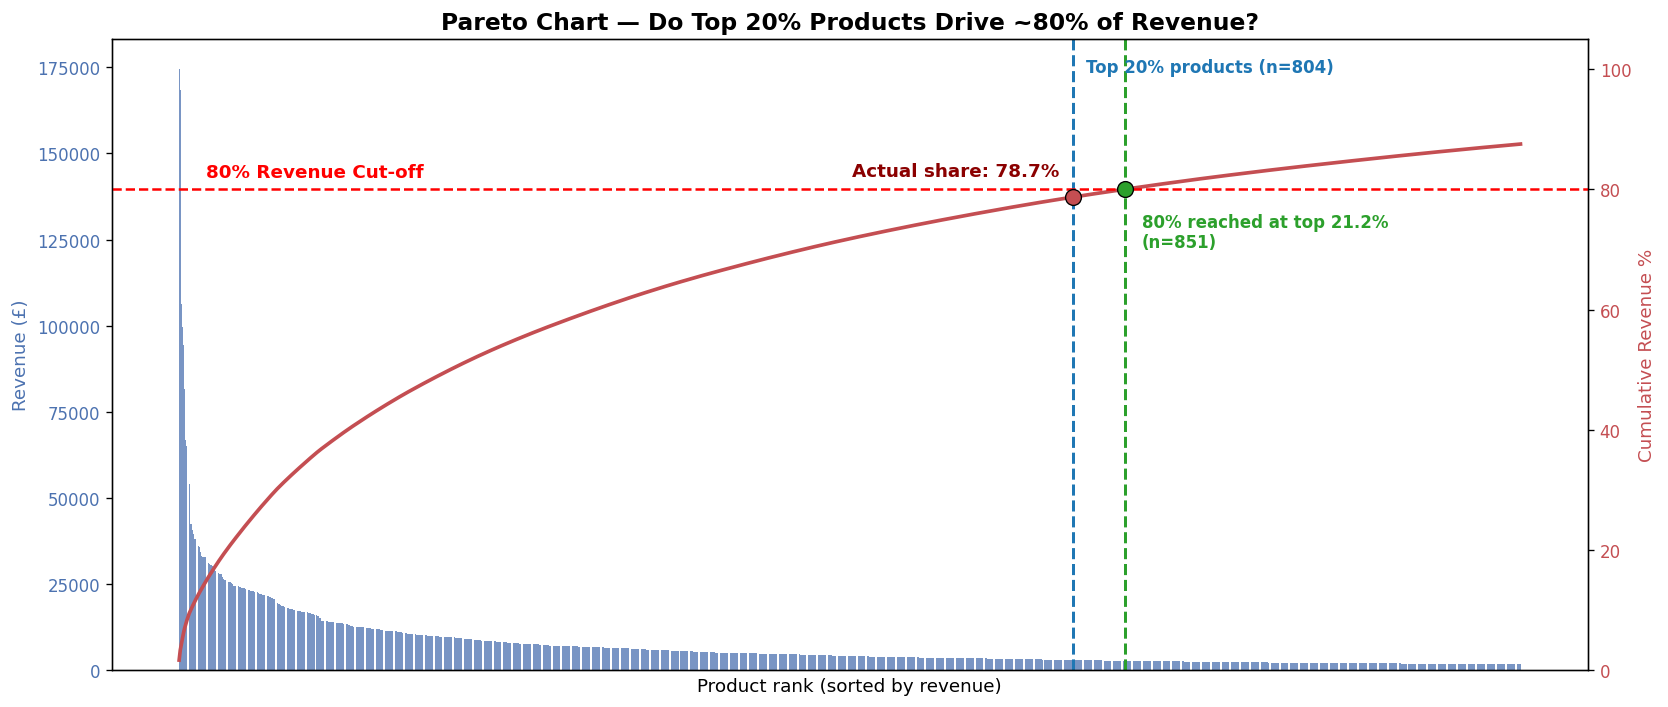

Top 20% products : 804 / 4,020
Actual revenue share at top 20%: 78.7%
Products needed to reach 80% revenue: 851 (21.2% of products)


In [157]:
# ==========================================================
# Viz 1 — Pareto Chart (20% products vs actual revenue share)
# 시각화 1 — 파레토 차트 (상위 20% 상품의 실제 매출 비중 검증)
# ==========================================================

# Where cumulative revenue first reaches 80%
n_for_80 = int((pareto["cumulative_pct"] >= 80).values.argmax()) + 1
pct_products_for_80 = n_for_80 / len(pareto) * 100
x_80 = n_for_80 - 1  # 0-based index

# X range: ~30% of products, but always include the 80% cut-off point
n_plot = max(int(len(pareto) * 0.30), int(n_for_80 * 1.15), 1)
n_plot = min(n_plot, len(pareto))
pareto_plot = pareto.head(n_plot).copy()
x = range(n_plot)

# Top 20% product count and actual cumulative revenue share at that point
top_20pct_n = max(int(len(pareto) * 0.20), 1)
x_20 = min(top_20pct_n - 1, n_plot - 1)  # 0-based index for plotting
actual_share = pareto.iloc[x_20]["cumulative_pct"]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left Y: individual revenue bars
ax1.bar(x, pareto_plot["Revenue"], color="#4C72B0", alpha=0.75, label="Revenue")
ax1.set_xlabel("Product rank (sorted by revenue)", fontsize=11)
ax1.set_ylabel("Revenue (£)", color="#4C72B0", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.set_xticks([])

# Right Y: cumulative %
ax2 = ax1.twinx()
ax2.plot(x, pareto_plot["cumulative_pct"], color="#C44E52", linewidth=2.2, label="Cumulative %")
ax2.set_ylabel("Cumulative Revenue %", color="#C44E52", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.set_ylim(0, 105)

# Reference line 1 — 80% revenue target (horizontal)
ax2.axhline(80, color="red", linestyle="--", linewidth=1.5)
ax2.text(n_plot * 0.02, 82, "80% Revenue Cut-off", color="red", fontsize=11, fontweight="bold")

# Reference line 2 — top 20% products (vertical, blue)
ax1.axvline(x_20, color="#1f77b4", linestyle="--", linewidth=1.8)
ax1.text(
    x_20 + n_plot * 0.01, ax1.get_ylim()[1] * 0.97,
    f"Top 20% products (n={top_20pct_n:,})",
    color="#1f77b4", fontsize=10, fontweight="bold",
    va="top",
)

# Reference line 3 — products needed to reach 80% revenue (vertical, green)
ax1.axvline(x_80, color="#2ca02c", linestyle="--", linewidth=1.8)

# Intersection marker — actual share at top 20%
ax2.scatter([x_20], [actual_share], color="#C44E52", s=90, zorder=5, edgecolor="black", linewidth=0.8)
# Label: top-left of the red point (no arrow)
ax2.annotate(
    f"Actual share: {actual_share:.1f}%",
    xy=(x_20, actual_share),
    xytext=(-8, 10),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    color="#8B0000",
    ha="right",
    va="bottom",
)

# Intersection marker — where cumulative % hits 80%
ax2.scatter([x_80], [80], color="#2ca02c", s=90, zorder=5, edgecolor="black", linewidth=0.8)
# Label: bottom-right of the green point (away from the Pareto line)
ax2.annotate(
    f"80% reached at top {pct_products_for_80:.1f}%\n(n={n_for_80:,})",
    xy=(x_80, 80),
    xytext=(10, -14),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    color="#2ca02c",
    ha="left",
    va="top",
)

ax1.set_title(
    "Pareto Chart — Do Top 20% Products Drive ~80% of Revenue?",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout()
plt.show()

print(f"Top 20% products : {top_20pct_n:,} / {len(pareto):,}")
print(f"Actual revenue share at top 20%: {actual_share:.1f}%")
print(f"Products needed to reach 80% revenue: {n_for_80:,} ({pct_products_for_80:.1f}% of products)")


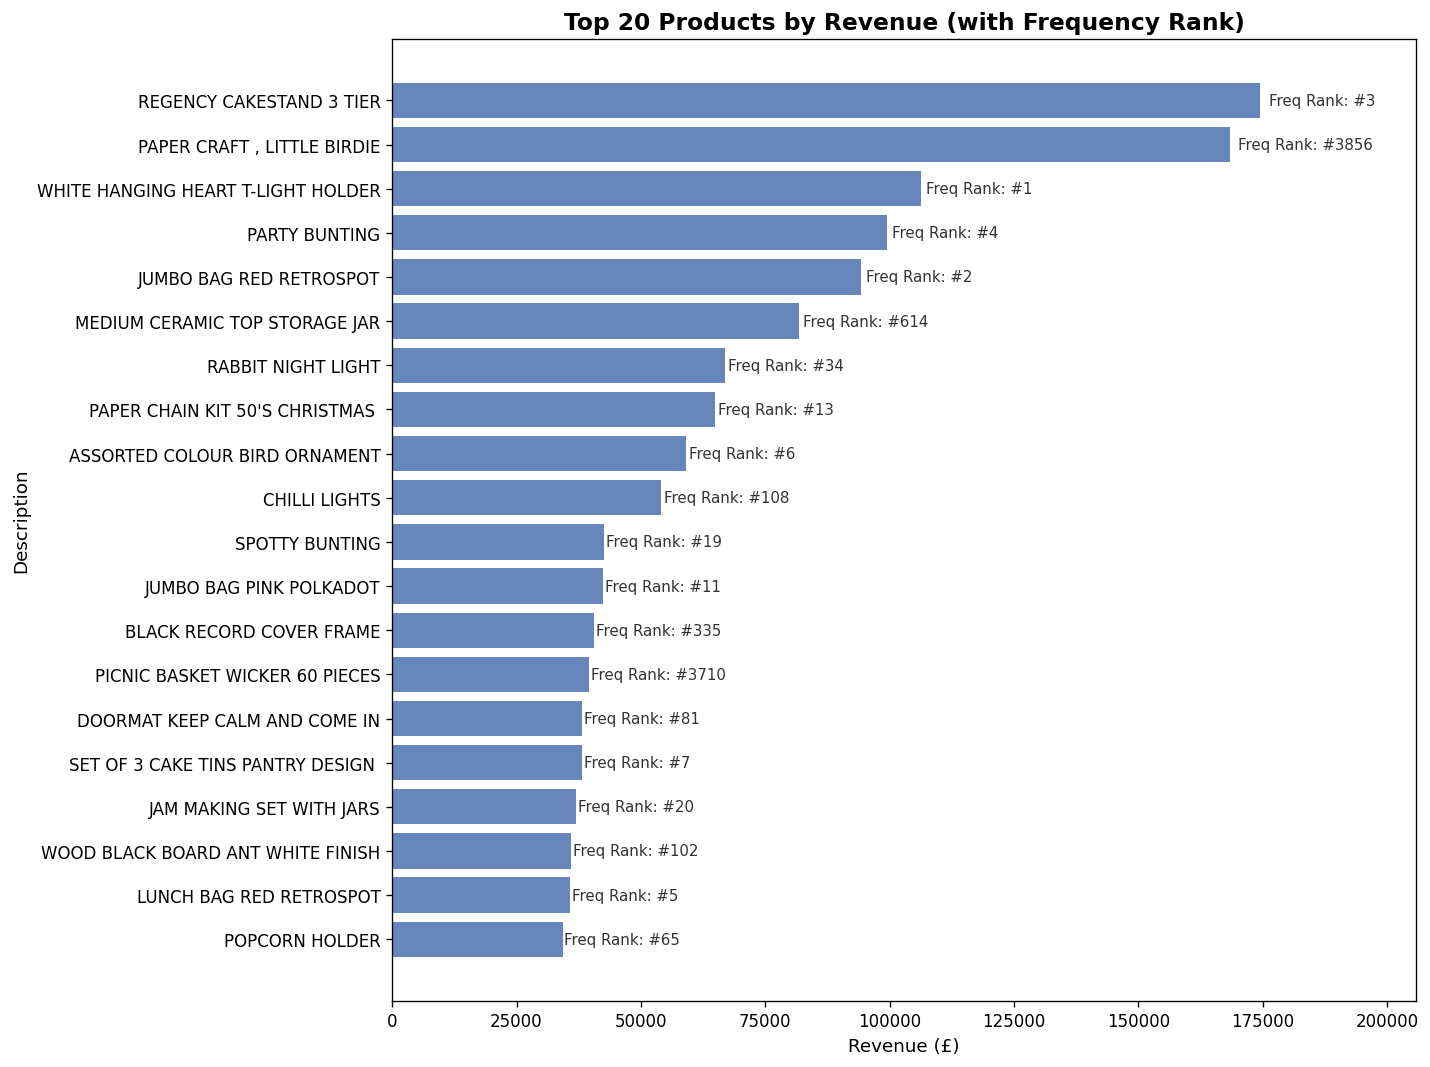

In [158]:
# ==========================================================
# Viz 2 — Top 20 Revenue Bar Chart + Frequency Rank Labels
# 시각화 2 — 매출 Top 20 가로 막대 + 판매량(빈도) 순위 라벨
# ==========================================================

# Frequency rank for all products (1 = most frequent)
freq_rank = (
    filtered_df.groupby("Description")
    .size()
    .sort_values(ascending=False)
    .rank(method="min", ascending=False)
    .astype(int)
)

top20 = top_products_clean.head(20).sort_values(ascending=True)  # for horizontal bar

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(top20.index, top20.values, color="#4C72B0", alpha=0.85)

ax.set_xlabel("Revenue (£)", fontsize=11)
ax.set_ylabel("Description", fontsize=11)
ax.set_title("Top 20 Products by Revenue (with Frequency Rank)", fontsize=14, fontweight="bold")

# Annotate frequency rank at the end of each bar
for bar, desc in zip(bars, top20.index):
    rank = freq_rank.get(desc, None)
    label = f"Freq Rank: #{rank}" if rank is not None else "Freq Rank: —"
    ax.text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=9,
        color="#333333",
    )

ax.margins(x=0.18)
fig.tight_layout()
plt.show()


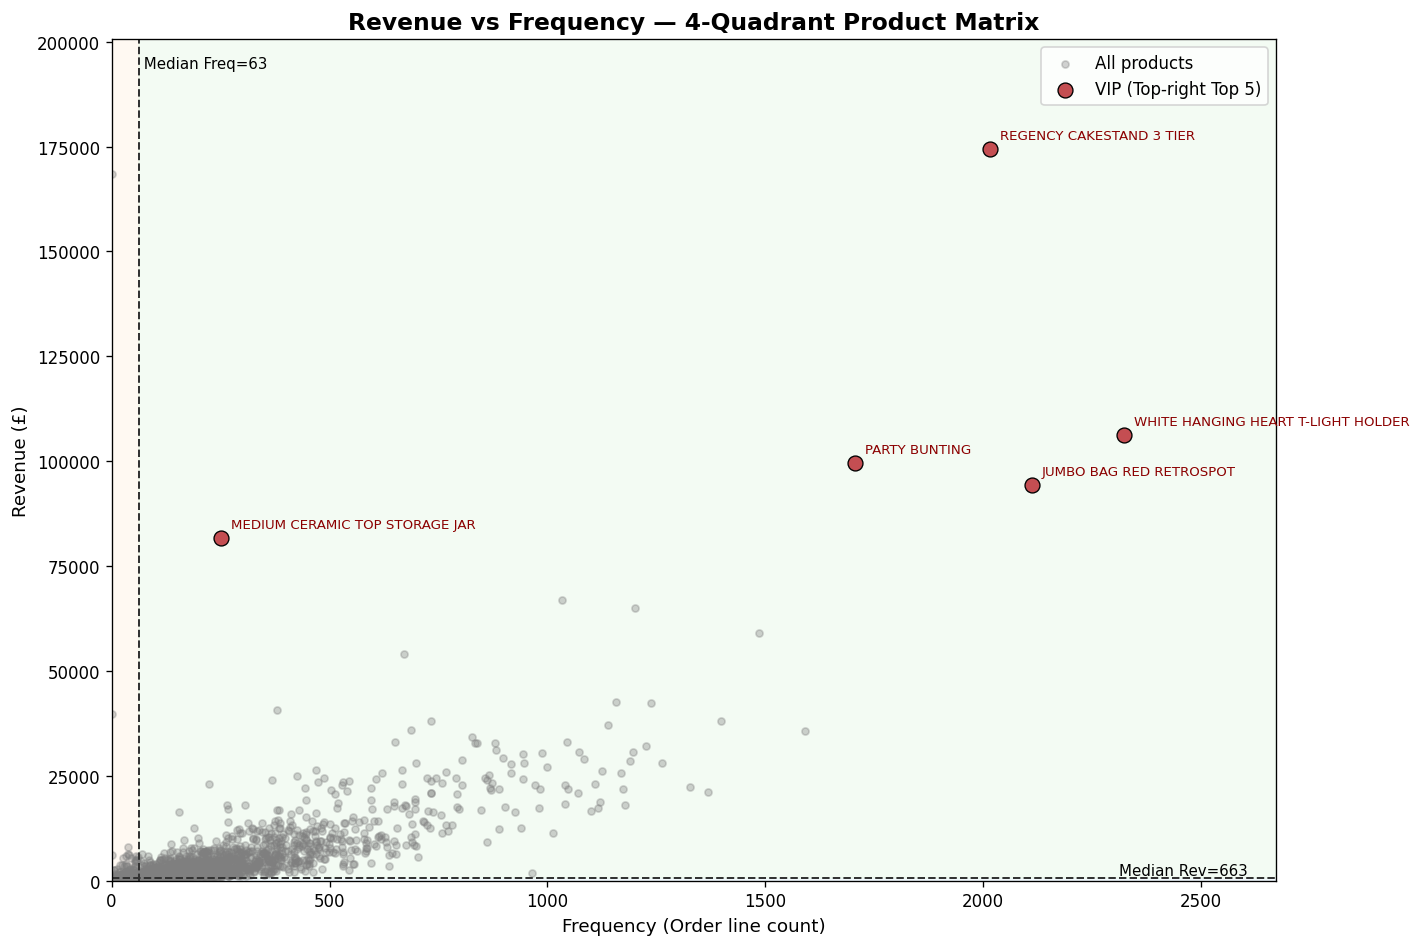

In [159]:
# ==========================================================
# Viz 3 — Revenue vs Frequency Scatter (4 Quadrants)
# 시각화 3 — 매출 vs 판매량 산점도 (4분면 매트릭스)
# ==========================================================

# Build product-level metrics
scatter_df = (
    filtered_df.groupby("Description")
    .agg(
        Revenue=("Revenue", "sum"),
        Frequency=("InvoiceNo", "count"),
    )
    .reset_index()
)

# Exclude non-product descriptions already identified
scatter_df = scatter_df[~scatter_df["Description"].isin(exclude_desc)]

x_med = scatter_df["Frequency"].median()
y_med = scatter_df["Revenue"].median()

# VIP: high revenue + high frequency (top-right), pick top 5 by revenue
vip = (
    scatter_df[
        (scatter_df["Frequency"] >= x_med) &
        (scatter_df["Revenue"] >= y_med)
    ]
    .sort_values("Revenue", ascending=False)
    .head(5)
)

fig, ax = plt.subplots(figsize=(12, 8))

# Soft quadrant backgrounds
xlim = (0, scatter_df["Frequency"].max() * 1.15)  # 최대값보다 15% 더 넓게
ylim = (0, scatter_df["Revenue"].max() * 1.15)    # 최대값보다 15% 더 넓게
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.axvspan(xlim[0], x_med, ymin=0, ymax=(y_med - ylim[0]) / (ylim[1] - ylim[0]),
           color="#f0f0f0", alpha=0.5, zorder=0)  # low freq, low rev
ax.axvspan(x_med, xlim[1], ymin=0, ymax=(y_med - ylim[0]) / (ylim[1] - ylim[0]),
           color="#e8f4fc", alpha=0.5, zorder=0)  # high freq, low rev
ax.axvspan(xlim[0], x_med, ymin=(y_med - ylim[0]) / (ylim[1] - ylim[0]), ymax=1,
           color="#fff4e6", alpha=0.5, zorder=0)  # low freq, high rev
ax.axvspan(x_med, xlim[1], ymin=(y_med - ylim[0]) / (ylim[1] - ylim[0]), ymax=1,
           color="#e8f8e8", alpha=0.5, zorder=0)  # high freq, high rev (VIP zone)

# All products
ax.scatter(
    scatter_df["Frequency"], scatter_df["Revenue"],
    s=18, alpha=0.35, color="#7f7f7f", label="All products",
)

# VIP highlight
ax.scatter(
    vip["Frequency"], vip["Revenue"],
    s=80, color="#C44E52", edgecolor="black", linewidth=0.8,
    zorder=5, label="VIP (Top-right Top 5)",
)

for _, row in vip.iterrows():
    ax.annotate(
        row["Description"][:35],
        (row["Frequency"], row["Revenue"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color="#8B0000",
    )

# Median cross lines
ax.axvline(x_med, color="#333333", linestyle="--", linewidth=1.2)
ax.axhline(y_med, color="#333333", linestyle="--", linewidth=1.2)
ax.text(x_med, ylim[1] * 0.98, f" Median Freq={x_med:.0f}", va="top", fontsize=9)
ax.text(xlim[1] * 0.98, y_med, f"Median Rev={y_med:,.0f} ", ha="right", va="bottom", fontsize=9)

ax.set_xlabel("Frequency (Order line count)", fontsize=11)
ax.set_ylabel("Revenue (£)", fontsize=11)
ax.set_title("Revenue vs Frequency — 4-Quadrant Product Matrix", fontsize=14, fontweight="bold")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


### Observations
### 관찰 결과

> **English** — Product performance findings from revenue ranking, Pareto check, and the 4-quadrant matrix.  
> **한국어** — 매출 순위, 파레토 검증, 4분면 매트릭스에서 발견한 상품 성과 인사이트.

**Description Quality (상품명 품질)**
- Rows with `Description` NaN are already removed by the shared sales filter (`UnitPrice > 0`). No extra NaN-handling is needed for product analysis.  
  Description NaN 행은 `UnitPrice > 0` 필터에서 이미 걸러지므로, 상품 분석용으로 별도 NaN 처리는 필요 없다.
- After filtering, non-product descriptions still appear in the top revenue list (e.g. `DOTCOM POSTAGE`, `POSTAGE`, `CARRIAGE`, `Manual`, `AMAZON FEE`, `Adjust bad debt`) and must be excluded.  
  필터 후에도 상위 매출에 배송비·수수료·회계 조정 Description이 남아 있어 제외가 필요하다.

**Pareto Principle (파레토 원칙)**
- Top 20% of products account for about **78.7%** of revenue — close to, but **not** a strict 80/20 rule (~1.3% short).  
  상위 20% 상품이 매출의 약 **78.7%**를 차지한다. 80/20에 가깝지만 **엄밀히는 해당하지 않으며** 약 1.3%p 부족하다.
- About **~21%** of products are needed to reach 80% of revenue.  
  매출 80%에 도달하려면 상품의 약 **21%**가 필요하다.

**Revenue vs Frequency (매출 vs 판매 빈도)**
- High revenue ≠ high frequency. Example: `#2` by revenue (`PAPER CRAFT , LITTLE BIRDIE`) has frequency rank around **#3,856** (often only 1 huge order). `#6` by revenue (`MEDIUM CERAMIC TOP STORAGE JAR`) has frequency rank around **#616**.  
  매출 상위 ≠ 자주 팔림. 매출 2위는 빈도 약 3856위, 매출 6위는 빈도 약 616위다.
- Business meaning: these can look like **“효자 상품” (high revenue)**, but some are **one-off extreme bulk orders**. Check frequency before treating them as core bestsellers.  
  해석: 고단가·대량 주문형으로 보일 수 있지만, **1회성 초대량 주문 이상치**일 수도 있다. 핵심 베스트셀러로 보기 전에 주문 횟수를 확인해야 한다.
- True **core products** are high revenue **and** high frequency (e.g. `REGENCY CAKESTAND 3 TIER`, `WHITE HANGING HEART T-LIGHT HOLDER`, `JUMBO BAG RED RETROSPOT`).  
  진짜 핵심 상품은 매출과 빈도가 모두 높은 상품이다.

**4-Quadrant Matrix Insights (4분면에서 얻는 것)**

| Quadrant | Meaning | Action |
|----------|---------|--------|
| **Top-right (VIP)** | High revenue + high frequency | Protect inventory & marketing focus |
| **Top-left** | High revenue + low frequency | Premium / bulk / check one-off outliers |
| **Bottom-right** | Low revenue + high frequency | Traffic drivers; review pricing |
| **Bottom-left** | Low revenue + low frequency | Long-tail; rationalisation candidates |

한국어 요약:
- **우상단(VIP):** 자주 팔리고 매출도 큼 → 재고·프로모션 우선 보호
- **좌상단:** 매출은 큰데 잘 안 팔림 → 대량/고단가 또는 이상치 점검
- **우하단:** 자주 팔리지만 매출은 작음 → 유입용 저가 상품, 가격/구성 검토
- **좌하단:** 둘 다 낮음 → 롱테일, 정리 후보

---

### Cleaning Decisions
### 전처리 결정

- [x] Keep shared sales filters: `Quantity > 0`, `UnitPrice > 0` (also removes most Description NaN rows)  
  공통 판매 필터 유지 — Description NaN(대부분 UnitPrice 0)도 함께 제거됨
- [x] Exclude non-product Descriptions from product analysis: `DOTCOM POSTAGE`, `POSTAGE`, `CARRIAGE`, `Manual`, `AMAZON FEE`, `Adjust bad debt`  
  상품 분석에서 비상품 Description 제외
- [x] Prefer also excluding via special StockCodes in pipeline (`POST`, `DOT`, `M`, `AMAZONFEE`, etc.)  
  pipeline에서는 StockCode 기준 제외도 함께 적용 검토
- [x] Interpret product performance with **both revenue and frequency** (4-quadrant), not revenue alone  
  상품 성과는 매출만 보지 말고 **빈도와 함께** 해석
- [ ] Optionally flag Frequency=1 + extreme Quantity products as outliers in analysis notes  
  주문 1회 + 초대량 Quantity 상품은 이상치로 표시 검토


---
## 7. Business Question 4 — Customer Purchase Behavior
## 고객 구매 행동 분석

### Business Question
**English:** How are customer order values distributed, and what portion of revenue comes from large orders?  
**한국어:** 고객 주문 금액 분포가 어떻게 되는가? 대형 주문이 매출에서 차지하는 비중은?

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `InvoiceNo` | Identify individual orders | 개별 주문 식별 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |

### EDA

#### 7-1. Cancellations — InvoiceNo starting with 'C'
**한국어** 취소 건 확인 — InvoiceNo가 C로 시작하는 행

In [160]:
# Cancellation count (InvoiceNo starts with 'C')
# 취소 건 수


#### 7-2. Order value per invoice
**한국어** 인보이스별 주문 금액 계산

In [161]:
# Order value = sum of (Quantity × UnitPrice) per InvoiceNo
# 인보이스별 주문 금액


#### 7-3. Descriptive statistics and outliers
**한국어** 기술 통계 및 이상값 확인

In [162]:
# describe() on order values
# 주문 금액 기술 통계


#### 7-4. Visualisation placeholder
**한국어** 시각화 자리

In [163]:
# TODO: Histogram — order value distribution
# TODO: Box plot — order value


### Observations
### 관찰 결과

> **English** — Is the distribution skewed? Are there extreme outliers that need capping?  
> **한국어** — 분포가 한쪽으로 치우쳐있는가? 극단값이 있어 처리가 필요한가?

- [ ] &nbsp;
- [ ] &nbsp;

### Cleaning Decisions
### 전처리 결정

- [ ] Exclude cancelled orders (`InvoiceNo` starting with `'C'`)
- [ ] &nbsp;

---
## 8. Business Question 5 — Customer Value Analysis
## 핵심 고객 분석

### Business Question
**English:** Who are the highest-value customers, and what do their purchase patterns look like?  
**한국어:** 가장 가치 있는 고객은 누구이며, 그들의 구매 패턴은 어떠한가?

---

### Relevant Columns
### 관련 컬럼

| Column | Why needed | 필요한 이유 |
|--------|-----------|------------|
| `CustomerID` | Identify individual customers | 개별 고객 식별 |
| `Quantity` | Part of Revenue calculation | 매출 계산 요소 |
| `UnitPrice` | Part of Revenue calculation | 매출 계산 요소 |
| `InvoiceDate` | Purchase frequency and recency | 구매 빈도 및 최근성 |

### EDA

#### 8-1. Missing CustomerID
**한국어** CustomerID 결측값 확인

In [164]:
# Missing CustomerID — count and percentage
# CustomerID 결측 수 및 비율


#### 8-2. What are the NaN CustomerID rows?
**한국어** CustomerID NaN 행의 특성 파악 — 게스트 구매인가, 다른 무언가인가?

In [165]:
# Pattern of rows with missing CustomerID
# (check UnitPrice, Quantity, Description patterns)
# CustomerID NaN 행 패턴 확인


#### 8-3. Customer revenue overview (excluding NaN CustomerID)
**한국어** 고객별 매출 개요 (CustomerID NaN 제외)

In [166]:
# Revenue per customer
# 고객별 매출


#### 8-4. Customer purchase frequency
**한국어** 고객별 구매 빈도

In [167]:
# Number of orders per customer
# 고객별 주문 수


#### 8-5. Visualisation placeholder
**한국어** 시각화 자리

In [168]:
# TODO: Bar chart — top 20 customers by revenue
# TODO: Summary table


### Observations
### 관찰 결과

> **English** — What % of rows have no CustomerID? Are they guest purchases or internal records?  
> **한국어** — CustomerID 없는 행이 전체의 몇 %인가? 게스트 구매인가, 내부 기록인가?

- [ ] &nbsp;
- [ ] &nbsp;

### Cleaning Decisions
### 전처리 결정

- [ ] For Q5 specifically, exclude rows where `CustomerID` is NaN
- [ ] &nbsp;

---
## 9. Final Cleaning Decisions
## 최종 전처리 계획

**English**

Summarise all cleaning decisions from EDA into a single reference table.
This table will guide the implementation in `pipeline/clean.py`.

**한국어**

EDA에서 발견한 모든 전처리 결정을 하나의 참조 테이블로 정리한다.
이 테이블은 `pipeline/clean.py` 구현의 기준이 된다.

| Issue | Decision | Pipeline Function |
|-------|----------|-------------------|
| Negative `Quantity` | Remove cancelled transactions | `remove_cancelled()` |
| Negative `UnitPrice` | Remove invalid prices | `remove_invalid_prices()` |
| Revenue | Create `Revenue = Quantity × UnitPrice` | `create_revenue()` |
| `InvoiceDate` | Convert to datetime | `convert_datetime()` |
| `Description` NaN | Remove rows with no product name | `remove_missing_description()` |
| Special `StockCode` | Remove non-product entries | `remove_special_stockcodes()` |
| `CustomerID` NaN | Exclude only for customer-level analysis (Q5) | `filter_known_customers()` |
| | | |
| | | |

> **Notes (참고사항):**
> - Add rows as new decisions are made during EDA.
> - 새로운 전처리 결정이 생기면 행을 추가한다.

---
## 10. Pipeline Implementation Plan
## Pipeline 구현 계획

**English**

Once EDA is complete and all cleaning decisions are validated in this notebook,
the logic will be moved into the `pipeline/` package as reusable, testable functions.

**한국어**

EDA가 완료되고 모든 전처리 결정이 노트북에서 검증되면,
해당 로직은 `pipeline/` 패키지의 재사용 가능하고 테스트 가능한 함수로 이동된다.

---

```
Notebook (실험)
        ↓
Experiment & Observe (탐색 및 관찰)
        ↓
Cleaning Decision (전처리 결정)
        ↓
Pipeline Function (함수로 구현)
        ↓
Reusable, Testable Code (재사용 가능한 코드)
```

---

### File Responsibilities
### 파일별 역할

| File | Responsibility | 역할 |
|------|---------------|------|
| `pipeline/load.py` | Load raw data | 원본 데이터 로드 |
| `pipeline/clean.py` | Apply all cleaning rules | 전처리 규칙 적용 |
| `pipeline/analyze.py` | Answer business questions | 비즈니스 질문에 답 |
| `pipeline/visualize.py` | Produce charts | 차트 생성 |
| `main.py` | Orchestrate the full pipeline | 전체 파이프라인 실행 |